# English → French Translation with Seq2Seq (PyTorch)

**Workshop notebook** — we will build a neural machine translation model from scratch using **PyTorch**.

### What you will build
A **sequence-to-sequence (Seq2Seq)** model that reads an English sentence and generates a French sentence, token by token:

`I am happy` → `je suis heureux`

### Architecture at a glance
1. **Encoder** — Bidirectional LSTM that reads the English sentence and builds a memory of it
2. **Attention** — at each decoding step, decide *which English words matter right now*
3. **Decoder** — LSTM that writes the French sentence one word at a time

### Learning goals
- Why encoder–decoder models are used for translation
- How **teacher forcing** works during training
- How **Luong (dot-product) attention** is computed
- Why padding must be ignored in the loss (a common accuracy trap)
- How training and inference are different

> **Runtime tip:** enable a GPU (Kaggle / Colab / local CUDA). CPU works, but training will be slower.


## 1. Setup and configuration

In [ ]:
import os
import re
import math
import time
import random
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")


Using device: cuda
GPU: Tesla T4


### Workshop knobs

`WORKSHOP_MODE = True` trains on a subset so a live session can finish in a reasonable time. Set it to `False` when you want the full-data run (closer to the original notebook).


In [ ]:
# True  = faster demo (recommended during the workshop)
# False = full dataset, closer to the original TensorFlow notebook
WORKSHOP_MODE = True

CONFIG = {
    "subset_size": 40_000 if WORKSHOP_MODE else None,  # None = use all pairs
    "max_vocab_size": 8_000 if WORKSHOP_MODE else 10_000,
    "max_seq_len": 20 if WORKSHOP_MODE else 40,
    "embed_dim": 256,
    "hidden_dim": 256,          # encoder hidden size (per direction)
    "decoder_hidden": 512,      # 256 * 2 after we merge bidirectional states
    "batch_size": 64,
    "epochs": 8 if WORKSHOP_MODE else 15,
    "learning_rate": 1e-3,
    "dropout": 0.2,
    "patience": 3,              # early stopping
    "grad_clip": 1.0,
    "num_workers": 0,           # keep 0 on Windows / notebooks
}

print("Training config")
for key, value in CONFIG.items():
    print(f"  {key:16s}: {value}")


Training config
  subset_size     : 40000
  max_vocab_size  : 8000
  max_seq_len     : 20
  embed_dim       : 256
  hidden_dim      : 256
  decoder_hidden  : 512
  batch_size      : 64
  epochs          : 8
  learning_rate   : 0.001
  dropout         : 0.2
  patience        : 3
  grad_clip       : 1.0
  num_workers     : 0


## 2. Load the dataset

In [ ]:
from pathlib import Path

for p in Path("/kaggle/input").rglob("*"):
    if p.is_file():
        print(p)

In [ ]:
def _read_csv_pairs(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    # Kaggle file uses English / French column names
    cols = {c.lower().strip(): c for c in df.columns}
    eng_col = cols.get("english") or cols.get("en") or list(df.columns)[0]
    fr_col = cols.get("french") or cols.get("fr") or list(df.columns)[1]
    out = df[[eng_col, fr_col]].copy()
    out.columns = ["English", "French"]
    return out.dropna()


def _read_tsv_pairs(path: str) -> pd.DataFrame:
    rows = []
    with open(path, encoding="utf-8") as f:
        for line in f:
            parts = line.rstrip("\n").split("\t")
            if len(parts) >= 2:
                rows.append((parts[0], parts[1]))
    return pd.DataFrame(rows, columns=["English", "French"])


def _download_anki_fra_eng(dest_dir: Path) -> Path:
    """Official PyTorch tutorial data: English \\t French pairs."""
    import urllib.request
    import zipfile

    dest_dir.mkdir(parents=True, exist_ok=True)
    zip_path = dest_dir / "anki_data.zip"
    txt_path = dest_dir / "eng-fra.txt"
    if txt_path.exists():
        return txt_path

    url = "https://download.pytorch.org/tutorial/data.zip"
    print(f"Downloading translation pairs from {url} ...")
    urllib.request.urlretrieve(url, zip_path)
    with zipfile.ZipFile(zip_path, "r") as zf:
        # archive contains data/eng-fra.txt
        for name in zf.namelist():
            if name.endswith("eng-fra.txt"):
                zf.extract(name, dest_dir)
                extracted = dest_dir / name
                extracted.replace(txt_path)
                break
    print(f"Saved to {txt_path}")
    return txt_path


def load_translation_dataframe() -> pd.DataFrame:
    candidates = [
        "/kaggle/input/datasets/devicharith/language-translation-englishfrench/eng_-french.csv",
        "eng_-french.csv",
        str(Path.home() / "Downloads" / "eng_-french.csv"),
        str(Path.cwd() / "eng_-french.csv"),
    ]
    for path in candidates:
        if os.path.exists(path):
            print(f"Loaded local CSV: {path}")
            return _read_csv_pairs(path)

    txt_path = _download_anki_fra_eng(Path.cwd() / "data")
    print(f"Loaded Anki / Tatoeba file: {txt_path}")
    return _read_tsv_pairs(txt_path)


df = load_translation_dataframe()
df = df[df["English"].astype(str).str.strip().ne("") & df["French"].astype(str).str.strip().ne("")]
df = df.drop_duplicates(subset=["English", "French"]).reset_index(drop=True)

if CONFIG["subset_size"] is not None and len(df) > CONFIG["subset_size"]:
    df = df.sample(n=CONFIG["subset_size"], random_state=SEED).reset_index(drop=True)
    print(f"Workshop subset: using {len(df):,} sentence pairs")
else:
    print(f"Using the full cleaned set: {len(df):,} sentence pairs")

df.head(8)

Saved to /content/data/eng-fra.txt
Loaded Anki / Tatoeba file: /content/data/eng-fra.txt
Workshop subset: using 40,000 sentence pairs


,English,French
0,"The wind was so strong, we were nearly blown o...",Le vent était tellement fort que nous avons pr...
1,You can never be happy if you feel envious of ...,Tu ne peux jamais être heureux si tu te sens e...
2,Let's reconsider the problem.,Reconsidérons le problème !
3,"Stop it, please.","Cessez, je vous prie !"
4,You are the one.,Vous êtes celui-là.
5,"No matter what you do, do your best.","Qu'importe ce que tu fais, fais de ton mieux !"
6,Why don't you get a haircut?,Pourquoi ne te fais-tu pas couper les cheveux ?
7,We buy stationery in bulk.,Nous achetons la papeterie en gros.


### Quick look at the data

Before cleaning, check length and a few raw examples. Most everyday sentences in this corpus are short — that is why a max length of 20 is enough in workshop mode.


Pairs: 40,000

Random examples:
  EN: I strongly advise you to use this.
  FR: Je te conseille vivement d'employer ceci.

  EN: I want to know about you.
  FR: Je veux savoir des choses à ton propos.

  EN: They crossed the border.
  FR: Ils traversèrent la frontière.

  EN: No matter how hard I practiced, I wasn't able to do the backstroke.
  FR: J'avais beau m'y entraîner, j'étais incapable de faire le dos crawlé.

  EN: He is a mathematical genius.
  FR: C'est un mathématicien de génie.

English words  — mean 6.2, max 34
French words   — mean 6.7, max 47


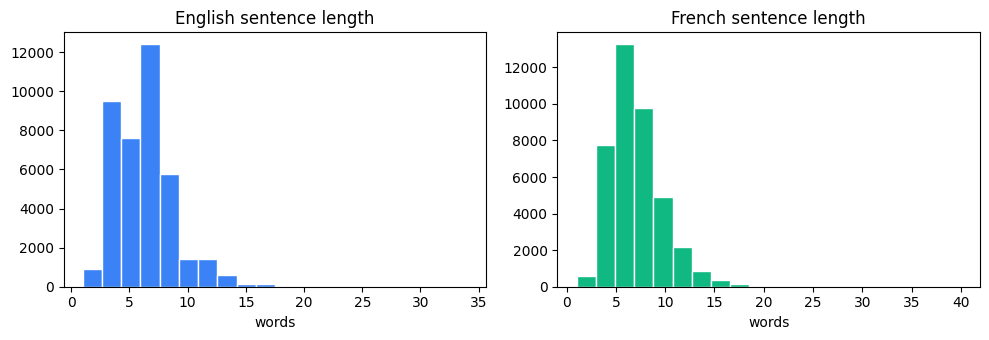

In [ ]:
print(f"Pairs: {len(df):,}")
print("\nRandom examples:")
for _, row in df.sample(5, random_state=SEED).iterrows():
    print(f"  EN: {row['English']}")
    print(f"  FR: {row['French']}\n")

eng_lens = df["English"].astype(str).str.split().str.len()
fr_lens = df["French"].astype(str).str.split().str.len()
print(f"English words  — mean {eng_lens.mean():.1f}, max {eng_lens.max()}")
print(f"French words   — mean {fr_lens.mean():.1f}, max {fr_lens.max()}")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].hist(eng_lens.clip(upper=40), bins=20, color="#3b82f6", edgecolor="white")
axes[0].set_title("English sentence length")
axes[0].set_xlabel("words")
axes[1].hist(fr_lens.clip(upper=40), bins=20, color="#10b981", edgecolor="white")
axes[1].set_title("French sentence length")
axes[1].set_xlabel("words")
plt.tight_layout()
plt.show()


## 3. Text cleaning

Neural models need consistent input. We:

1. Lowercase everything (`Hi.` and `hi` should be the same token)
2. Expand a few common contractions (`don't` → `do not`)
3. Keep letters (and French accents) and spaces, drop the rest
4. Collapse repeated spaces

We do **not** add `<start>` / `<end>` here. Those special tokens are added later, when we convert text to IDs. That is cleaner than baking them into the raw strings.


In [ ]:
EN_CONTRACTIONS = {
    "i'm": "i am", "you're": "you are", "he's": "he is", "she's": "she is",
    "it's": "it is", "we're": "we are", "they're": "they are",
    "i've": "i have", "you've": "you have", "we've": "we have", "they've": "they have",
    "i'll": "i will", "you'll": "you will", "he'll": "he will", "she'll": "she will",
    "we'll": "we will", "they'll": "they will",
    "isn't": "is not", "aren't": "are not", "wasn't": "was not", "weren't": "were not",
    "don't": "do not", "doesn't": "does not", "didn't": "did not",
    "can't": "cannot", "couldn't": "could not", "won't": "will not",
    "wouldn't": "would not", "shouldn't": "should not", "haven't": "have not",
    "hasn't": "has not", "hadn't": "had not", "let's": "let us",
}

FR_CONTRACTIONS = {
    "c'est": "ce est", "j'ai": "je ai", "n'est": "ne est",
    "qu'est": "que est", "d'accord": "de accord", "l'est": "le est",
}

# Letters we keep for French (accents + oe ligature)
FR_KEEP = r"a-zàâäçéèêëîïôùûüœÿ\s"


def _expand(text: str, table: dict) -> str:
    for src_tok, dst_tok in table.items():
        text = re.sub(rf"\b{re.escape(src_tok)}\b", dst_tok, text)
    return text


def clean_english(text: str) -> str:
    text = str(text).lower().strip()
    text = _expand(text, EN_CONTRACTIONS)
    text = re.sub(r"[^a-z\s]+", " ", text)
    return re.sub(r"\s+", " ", text).strip()


def clean_french(text: str) -> str:
    text = str(text).lower().strip()
    text = _expand(text, FR_CONTRACTIONS)
    text = re.sub(rf"[^{FR_KEEP}]+", " ", text)
    return re.sub(r"\s+", " ", text).strip()


df["English"] = df["English"].map(clean_english)
df["French"] = df["French"].map(clean_french)
df = df[(df["English"].str.len() > 0) & (df["French"].str.len() > 0)].reset_index(drop=True)

print("After cleaning:")
for _, row in df.head(5).iterrows():
    print(f"  {row['English']:30s}  →  {row['French']}")


After cleaning:
  the wind was so strong we were nearly blown off the road  →  le vent était tellement fort que nous avons presque été poussés en dehors de la route
  you can never be happy if you feel envious of other people  →  tu ne peux jamais être heureux si tu te sens envieux à l égard d autrui
  let us reconsider the problem   →  reconsidérons le problème
  stop it please                  →  cessez je vous prie
  you are the one                 →  vous êtes celui là


## 4. Train / validation / test split

We hold out **10% for test** (final numbers) and **10% of the remainder for validation** (early stopping). The vocabulary is built from the **training set only**, so the model never “sees” test words while building its dictionary.


In [ ]:
train_df, test_df = train_test_split(df, test_size=0.10, random_state=SEED)
train_df, val_df = train_test_split(train_df, test_size=0.10, random_state=SEED)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"Train: {len(train_df):,}")
print(f"Valid: {len(val_df):,}")
print(f"Test : {len(test_df):,}")


Train: 32,400
Valid: 3,600
Test : 4,000


## 5. Vocabulary and numericalization

A neural net cannot read strings. We map every word to an integer ID.

| Token | ID | Role |
|---|---|---|
| `<pad>` | 0 | Fills shorter sentences so a batch has one rectangular tensor |
| `<unk>` | 1 | Words that did not make the vocabulary cutoff |
| `<start>` | 2 | Tells the decoder “begin generating” |
| `<end>` | 3 | Tells the decoder “the sentence is finished” |

**Why `<start>` and `<end>`?**  
The decoder is a language model conditioned on the English sentence. It needs a first input token (`<start>`) and a stop signal (`<end>`). Without `<end>`, it would never know when to stop.


In [ ]:
class Vocabulary:
    """Word-level vocabulary with reserved special tokens."""

    PAD = "<pad>"
    UNK = "<unk>"
    SOS = "<start>"
    EOS = "<end>"

    def __init__(self, max_size: int = 10_000):
        self.max_size = max_size
        self.word2idx = {self.PAD: 0, self.UNK: 1, self.SOS: 2, self.EOS: 3}
        self.idx2word = {idx: word for word, idx in self.word2idx.items()}

    def build(self, sentences):
        counts = Counter()
        for sentence in sentences:
            counts.update(sentence.split())

        # Keep the most frequent words; reserve 4 slots for special tokens
        for word, _ in counts.most_common(self.max_size - 4):
            if word not in self.word2idx:
                idx = len(self.word2idx)
                self.word2idx[word] = idx
                self.idx2word[idx] = word
        return self

    def encode(self, sentence: str, max_len: int, add_special: bool = False):
        tokens = sentence.split()
        if add_special:
            tokens = [self.SOS] + tokens + [self.EOS]
        ids = [self.word2idx.get(tok, self.word2idx[self.UNK]) for tok in tokens]
        ids = ids[:max_len]
        length = len(ids)
        ids = ids + [self.word2idx[self.PAD]] * (max_len - length)
        return ids, length

    def decode(self, ids, skip_special: bool = True):
        special = {self.PAD, self.UNK, self.SOS, self.EOS} if skip_special else set()
        words = []
        for idx in ids:
            word = self.idx2word.get(int(idx), self.UNK)
            if word == self.EOS:
                break
            if word in special:
                continue
            words.append(word)
        return " ".join(words)

    def __len__(self):
        return len(self.word2idx)

    @property
    def pad_idx(self):
        return self.word2idx[self.PAD]

    @property
    def sos_idx(self):
        return self.word2idx[self.SOS]

    @property
    def eos_idx(self):
        return self.word2idx[self.EOS]

    @property
    def unk_idx(self):
        return self.word2idx[self.UNK]


src_vocab = Vocabulary(CONFIG["max_vocab_size"]).build(train_df["English"])
tgt_vocab = Vocabulary(CONFIG["max_vocab_size"]).build(train_df["French"])

print(f"English vocab size: {len(src_vocab):,}")
print(f"French vocab size : {len(tgt_vocab):,}")
print("Sample English IDs:", list(src_vocab.word2idx.items())[:8])
print("Sample French IDs :", list(tgt_vocab.word2idx.items())[:8])


English vocab size: 7,733
French vocab size : 8,000
Sample English IDs: [('<pad>', 0), ('<unk>', 1), ('<start>', 2), ('<end>', 3), ('i', 4), ('you', 5), ('to', 6), ('the', 7)]
Sample French IDs : [('<pad>', 0), ('<unk>', 1), ('<start>', 2), ('<end>', 3), ('je', 4), ('de', 5), ('pas', 6), ('vous', 7)]


## 6. Dataset and DataLoader

Each training example is three tensors:

- `src` — English IDs, shape `(max_len,)`
- `tgt_in` — French IDs **with `<start>`**, used as decoder input
- `tgt_out` — French IDs **shifted left** (the next word the decoder should predict), ending with `<end>`

Example for `bonjour` (simplified):

```
tgt_in  = [<start>, bonjour, <end>, <pad>, ...]
tgt_out = [bonjour, <end>,   <pad>, <pad>, ...]
```

The model sees `tgt_in[t]` and must predict `tgt_out[t]`. That is **teacher forcing**: during training we feed the *correct* previous word, not the model’s own prediction. Training becomes much more stable.

> The original Keras notebook did the same thing by passing the full French sequence as decoder input and `french[:, 1:]` as the target.


In [ ]:
class TranslationDataset(Dataset):
    def __init__(self, frame, src_vocab, tgt_vocab, max_len):
        self.src_texts = frame["English"].tolist()
        self.tgt_texts = frame["French"].tolist()
        self.src_vocab = src_vocab
        self.tgt_vocab = tgt_vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.src_texts)

    def __getitem__(self, idx):
        src_ids, src_len = self.src_vocab.encode(
            self.src_texts[idx], self.max_len, add_special=False
        )
        tgt_ids, tgt_len = self.tgt_vocab.encode(
            self.tgt_texts[idx], self.max_len, add_special=True
        )
        # Decoder input = everything except the last token
        # Decoder target = everything except <start>
        tgt_in = tgt_ids[:-1]
        tgt_out = tgt_ids[1:]
        return {
            "src": torch.tensor(src_ids, dtype=torch.long),
            "src_len": torch.tensor(src_len, dtype=torch.long),
            "tgt_in": torch.tensor(tgt_in, dtype=torch.long),
            "tgt_out": torch.tensor(tgt_out, dtype=torch.long),
            "src_text": self.src_texts[idx],
            "tgt_text": self.tgt_texts[idx],
        }


def make_loader(frame, shuffle):
    dataset = TranslationDataset(frame, src_vocab, tgt_vocab, CONFIG["max_seq_len"])
    return DataLoader(
        dataset,
        batch_size=CONFIG["batch_size"],
        shuffle=shuffle,
        num_workers=CONFIG["num_workers"],
        drop_last=False,
    )


train_loader = make_loader(train_df, shuffle=True)
val_loader = make_loader(val_df, shuffle=False)
test_loader = make_loader(test_df, shuffle=False)

batch = next(iter(train_loader))
print("Batch tensor shapes")
print(f"  src     {tuple(batch['src'].shape)}     # (batch, src_len)")
print(f"  tgt_in  {tuple(batch['tgt_in'].shape)}  # (batch, tgt_len - 1)")
print(f"  tgt_out {tuple(batch['tgt_out'].shape)} # (batch, tgt_len - 1)")
print()
print("Text :", batch["src_text"][0], "→", batch["tgt_text"][0])
print("src  :", batch["src"][0].tolist()[:12])
print("in   :", batch["tgt_in"][0].tolist()[:12])
print("out  :", batch["tgt_out"][0].tolist()[:12])


Batch tensor shapes
  src     (64, 20)     # (batch, src_len)
  tgt_in  (64, 19)  # (batch, tgt_len - 1)
  tgt_out (64, 19) # (batch, tgt_len - 1)

Text : i am looking for a jewelry store → je cherche une bijouterie
src  : [4, 24, 235, 27, 9, 3242, 695, 0, 0, 0, 0, 0]
in   : [2, 4, 887, 26, 1, 3, 0, 0, 0, 0, 0, 0]
out  : [4, 887, 26, 1, 3, 0, 0, 0, 0, 0, 0, 0]


## 7. Model: Seq2Seq with attention

### 7.1 Why encoder–decoder?

Translation is a **sequence-to-sequence** problem: the input and output have different lengths and different word orders.

```
English (source)          French (target)
I     love   cats    →    j'   aime   les   chats
```

A single LSTM that reads English and immediately writes French would struggle, because it would have to start generating before it has seen the full source sentence. The encoder–decoder split fixes that:

- The **encoder** reads the *entire* English sentence first
- The **decoder** then writes French, looking back at the encoder memory

### 7.2 Bidirectional LSTM encoder

A normal LSTM reads left → right. A **bidirectional** LSTM also reads right → left, then concatenates both hidden states.

That helps because the meaning of a word often depends on both sides:

`bank` in `river bank` vs `bank account`

Encoder hidden size is `256` per direction, so the concatenated state is `512`. The decoder LSTM therefore uses hidden size `512` so it can be initialized from those states.

### 7.3 Luong / dot-product attention

The original “bottleneck” Seq2Seq compressed the whole sentence into one vector. Attention lets the decoder **look at every encoder step** and pick what is relevant.

For one decoder step, with query \(q\) (decoder hidden) and encoder memory \(K\) (all encoder outputs):

$$
\text{scores} = q \cdot K^\top
$$

$$
\alpha = \mathrm{softmax}(\text{scores})
$$

$$
\text{context} = \alpha \cdot V
$$

Intuition: \(\alpha\) is a probability distribution over English words. The context vector is a weighted summary of the source sentence for *this* French word.

We then concatenate `[decoder_output ; context]` and project to the French vocabulary.

This is the same idea as the custom `AttentionLayer` in the TensorFlow notebook, with one important upgrade: **we mask pad positions** so the model cannot attend to padding.


In [ ]:
class Encoder(nn.Module):
    """Bidirectional LSTM encoder.

    Input : (batch, src_len) token IDs
    Output: encoder_outputs (batch, src_len, 2*hidden)
            hidden, cell    (1, batch, 2*hidden)  — merged directions
    """

    def __init__(self, vocab_size, embed_dim, hidden_dim, pad_idx, dropout=0.2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(
            embed_dim,
            hidden_dim,
            num_layers=1,
            batch_first=True,
            bidirectional=True,
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, src):
        # src: (B, S)
        embedded = self.dropout(self.embedding(src))          # (B, S, E)
        outputs, (hidden, cell) = self.lstm(embedded)         # outputs: (B, S, 2H)
        # hidden/cell come as (2, B, H) = [forward; backward]
        hidden = torch.cat([hidden[0], hidden[1]], dim=-1).unsqueeze(0)  # (1, B, 2H)
        cell = torch.cat([cell[0], cell[1]], dim=-1).unsqueeze(0)
        return outputs, hidden, cell


class LuongAttention(nn.Module):
    """Dot-product attention with optional padding mask."""

    def forward(self, decoder_outputs, encoder_outputs, src_mask=None):
        # decoder_outputs: (B, T, H)
        # encoder_outputs: (B, S, H)
        scores = torch.bmm(decoder_outputs, encoder_outputs.transpose(1, 2))  # (B, T, S)
        if src_mask is not None:
            # src_mask: (B, S) True = keep, False = pad
            scores = scores.masked_fill(~src_mask.unsqueeze(1), -1e9)
        weights = F.softmax(scores, dim=-1)                   # (B, T, S)
        context = torch.bmm(weights, encoder_outputs)         # (B, T, H)
        return context, weights


class Decoder(nn.Module):
    """LSTM decoder + attention + vocab projection.

    Works on a full target sequence (training) or a single token (inference).
    """

    def __init__(self, vocab_size, embed_dim, hidden_dim, pad_idx, dropout=0.2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=1, batch_first=True)
        self.attention = LuongAttention()
        # concat(decoder_out, context) → vocab
        self.fc = nn.Linear(hidden_dim * 2, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, tgt_in, hidden, cell, encoder_outputs, src_mask=None):
        embedded = self.dropout(self.embedding(tgt_in))       # (B, T, E)
        dec_out, (hidden, cell) = self.lstm(embedded, (hidden, cell))  # (B, T, H)
        context, attn = self.attention(dec_out, encoder_outputs, src_mask)
        combined = torch.cat([dec_out, context], dim=-1)      # (B, T, 2H)
        logits = self.fc(combined)                            # (B, T, V)
        return logits, hidden, cell, attn


class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, pad_idx):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.pad_idx = pad_idx

    def create_src_mask(self, src):
        return src != self.pad_idx  # (B, S) True = real token

    def forward(self, src, tgt_in):
        encoder_outputs, hidden, cell = self.encoder(src)
        src_mask = self.create_src_mask(src)
        logits, _, _, attn = self.decoder(
            tgt_in, hidden, cell, encoder_outputs, src_mask
        )
        return logits, attn


In [ ]:
encoder = Encoder(
    vocab_size=len(src_vocab),
    embed_dim=CONFIG["embed_dim"],
    hidden_dim=CONFIG["hidden_dim"],
    pad_idx=src_vocab.pad_idx,
    dropout=CONFIG["dropout"],
)
decoder = Decoder(
    vocab_size=len(tgt_vocab),
    embed_dim=CONFIG["embed_dim"],
    hidden_dim=CONFIG["decoder_hidden"],
    pad_idx=tgt_vocab.pad_idx,
    dropout=CONFIG["dropout"],
)
model = Seq2Seq(encoder, decoder, pad_idx=src_vocab.pad_idx).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"\nTrainable parameters: {n_params:,}")


Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(7733, 256, padding_idx=0)
    (lstm): LSTM(256, 256, batch_first=True, bidirectional=True)
    (dropout): Dropout(p=0.2, inplace=False)
  )
  (decoder): Decoder(
    (embedding): Embedding(8000, 256, padding_idx=0)
    (lstm): LSTM(256, 512, batch_first=True)
    (attention): LuongAttention()
    (fc): Linear(in_features=1024, out_features=8000, bias=True)
    (dropout): Dropout(p=0.2, inplace=False)
  )
)

Trainable parameters: 14,857,280


## 8. Loss, metrics, and the padding trap

We use **cross-entropy** over the French vocabulary.

**Important workshop point:** the original Keras notebook reported ~96% accuracy. A large part of that number came from **padding tokens**. If 70% of a batch is `<pad>` and the model learns to predict pad after `<end>`, accuracy looks excellent even when the real words are mediocre.

In PyTorch we pass `ignore_index=PAD` so pad positions do **not** contribute to the loss or to our token accuracy. The number will look lower — and more honest.


In [ ]:
criterion = nn.CrossEntropyLoss(ignore_index=tgt_vocab.pad_idx)
optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG["learning_rate"])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=1
)


def token_accuracy(logits, targets, pad_idx):
    """Accuracy on non-pad tokens only."""
    preds = logits.argmax(dim=-1)
    mask = targets != pad_idx
    if mask.sum() == 0:
        return 0.0
    return (preds[mask] == targets[mask]).float().mean().item()


def run_epoch(loader, train: bool):
    if train:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    context = torch.enable_grad() if train else torch.no_grad()
    with context:
        for batch in loader:
            src = batch["src"].to(device)
            tgt_in = batch["tgt_in"].to(device)
            tgt_out = batch["tgt_out"].to(device)

            logits, _ = model(src, tgt_in)  # (B, T, V)
            loss = criterion(logits.reshape(-1, logits.size(-1)), tgt_out.reshape(-1))

            if train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), CONFIG["grad_clip"])
                optimizer.step()

            total_loss += loss.item()
            total_acc += token_accuracy(logits, tgt_out, tgt_vocab.pad_idx)
            n_batches += 1

    return total_loss / max(n_batches, 1), total_acc / max(n_batches, 1)


## 9. Training loop

Each epoch:

1. Encode English
2. Decode the full French sequence in one shot (teacher forcing)
3. Compare predicted tokens with `tgt_out`
4. Backpropagate, clip gradients, step the optimizer

**Early stopping** watches validation loss. If it does not improve for `patience` epochs, we restore the best weights and stop. That is the PyTorch equivalent of Keras `EarlyStopping(restore_best_weights=True)`.

**Gradient clipping** (`max_norm=1.0`) keeps LSTM training from exploding — a classic RNN issue.


In [ ]:
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val = math.inf
best_state = None
stale = 0
t0 = time.time()

print(f"{'epoch':>6}  {'train_loss':>11}  {'val_loss':>9}  {'train_acc':>10}  {'val_acc':>8}  {'time':>6}")
print("-" * 64)

for epoch in range(1, CONFIG["epochs"] + 1):
    epoch_start = time.time()
    train_loss, train_acc = run_epoch(train_loader, train=True)
    val_loss, val_acc = run_epoch(val_loader, train=False)
    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    elapsed = time.time() - epoch_start
    print(
        f"{epoch:6d}  {train_loss:11.4f}  {val_loss:9.4f}  "
        f"{train_acc:10.3f}  {val_acc:8.3f}  {elapsed:5.0f}s"
    )

    if val_loss < best_val - 1e-4:
        best_val = val_loss
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        stale = 0
    else:
        stale += 1
        if stale >= CONFIG["patience"]:
            print(f"Early stopping at epoch {epoch} (best val loss = {best_val:.4f})")
            break

if best_state is not None:
    model.load_state_dict(best_state)
    model.to(device)

print(f"\nFinished in {(time.time() - t0) / 60:.1f} min. Best val loss: {best_val:.4f}")


 epoch   train_loss   val_loss   train_acc   val_acc    time
----------------------------------------------------------------
     1       3.8598     2.5076       0.386     0.521     17s
     2       2.1461     1.9810       0.571     0.591     16s
     3       1.5410     1.7919       0.646     0.623     16s
     4       1.2096     1.7182       0.701     0.640     16s
     5       0.9971     1.6869       0.743     0.649     16s
     6       0.8521     1.6818       0.773     0.652     16s
     7       0.7412     1.6869       0.798     0.658     17s
     8       0.6547     1.6978       0.818     0.661     17s

Finished in 2.2 min. Best val loss: 1.6818


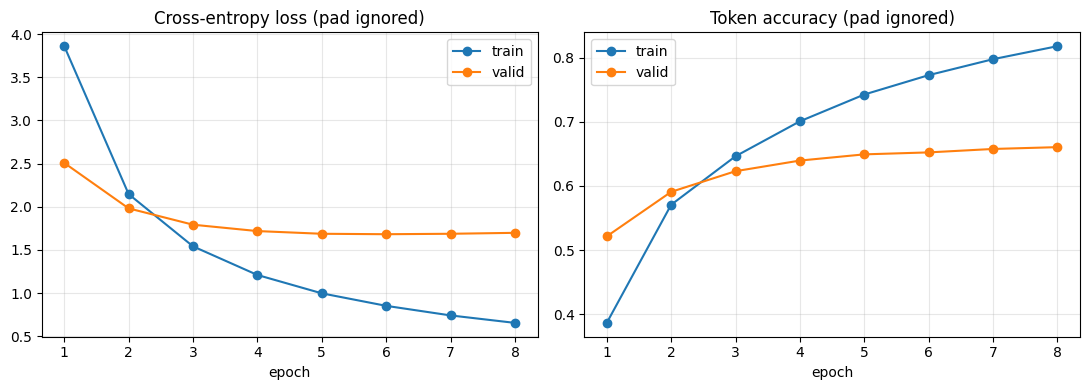

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
epochs_x = range(1, len(history["train_loss"]) + 1)

axes[0].plot(epochs_x, history["train_loss"], marker="o", label="train")
axes[0].plot(epochs_x, history["val_loss"], marker="o", label="valid")
axes[0].set_title("Cross-entropy loss (pad ignored)")
axes[0].set_xlabel("epoch")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_x, history["train_acc"], marker="o", label="train")
axes[1].plot(epochs_x, history["val_acc"], marker="o", label="valid")
axes[1].set_title("Token accuracy (pad ignored)")
axes[1].set_xlabel("epoch")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 10. Evaluation on the test set

Same metric as validation: loss and token accuracy, **padding ignored**.


In [ ]:
test_loss, test_acc = run_epoch(test_loader, train=False)
print(f"Test loss:     {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.3f}   ← non-pad French tokens only")


Test loss:     1.7030
Test accuracy: 0.654   ← non-pad French tokens only


## 11. Inference: translating a new sentence

Training used teacher forcing (the correct previous French word).  
**Inference cannot do that** — we do not have the French sentence yet.

Greedy decoding:

1. Encode the English sentence once
2. Feed `<start>` to the decoder
3. Pick the most likely next word (`argmax`)
4. Feed that word back in
5. Repeat until `<end>` or `max_len`

This is slower than training (one token per step) but it is how the model is actually used.

We also return the attention matrix so we can draw a heatmap: rows = generated French words, columns = English words.


In [ ]:
@torch.no_grad()
def translate_sentence(sentence: str, max_len: int = None, return_attention: bool = False):
    """Greedy decode one English sentence → French string."""
    model.eval()
    max_len = max_len or CONFIG["max_seq_len"]

    cleaned = clean_english(sentence)
    src_ids, src_len = src_vocab.encode(cleaned, CONFIG["max_seq_len"], add_special=False)
    src = torch.tensor(src_ids, dtype=torch.long, device=device).unsqueeze(0)  # (1, S)

    encoder_outputs, hidden, cell = model.encoder(src)
    src_mask = model.create_src_mask(src)

    token = torch.tensor([[tgt_vocab.sos_idx]], device=device)  # (1, 1)
    output_ids = []
    attn_steps = []

    for _ in range(max_len):
        logits, hidden, cell, attn = model.decoder(
            token, hidden, cell, encoder_outputs, src_mask
        )
        next_id = int(logits[0, -1].argmax())
        attn_steps.append(attn[0, 0, :src_len].detach().cpu())
        if next_id == tgt_vocab.eos_idx:
            break
        output_ids.append(next_id)
        token = torch.tensor([[next_id]], device=device)

    text = tgt_vocab.decode(output_ids)
    if return_attention:
        attn_mat = torch.stack(attn_steps, dim=0) if attn_steps else torch.zeros(1, src_len)
        src_tokens = cleaned.split()[:src_len]
        tgt_tokens = text.split()
        return text, src_tokens, tgt_tokens, attn_mat
    return text


def plot_attention(src_tokens, tgt_tokens, attn_mat, title="Attention"):
    if len(src_tokens) == 0 or len(tgt_tokens) == 0:
        print("Nothing to plot (empty translation).")
        return
    # attn_mat may have one extra row if we stopped on <end>
    rows = min(len(tgt_tokens), attn_mat.size(0))
    mat = attn_mat[:rows, :len(src_tokens)].numpy()

    fig, ax = plt.subplots(figsize=(max(4, 0.55 * len(src_tokens) + 2), max(3, 0.45 * rows + 1.5)))
    im = ax.imshow(mat, cmap="YlOrRd", aspect="auto", vmin=0, vmax=1)
    ax.set_xticks(range(len(src_tokens)))
    ax.set_xticklabels(src_tokens, rotation=45, ha="right")
    ax.set_yticks(range(rows))
    ax.set_yticklabels(tgt_tokens[:rows])
    ax.set_xlabel("English (source)")
    ax.set_ylabel("French (generated)")
    ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()


print(translate_sentence("I am very happy today"))
print(translate_sentence("Where is the parking?"))


je suis très heureuse aujourd hui
où est le


## 12. Qualitative results

Random test sentences: reference vs model output. Short, frequent phrases are usually better than long / rare ones — that is expected for a from-scratch LSTM on a limited vocabulary.


In [ ]:
def show_translations(n=10, seed=0):
    rng = random.Random(seed)
    indices = rng.sample(range(len(test_df)), k=min(n, len(test_df)))
    rows = []
    for i in indices:
        eng = test_df.loc[i, "English"]
        ref = test_df.loc[i, "French"]
        pred = translate_sentence(eng)
        rows.append({"English": eng, "Reference (FR)": ref, "Predicted (FR)": pred})
    return pd.DataFrame(rows)


translations_df = show_translations(n=12, seed=7)
pd.set_option("display.max_colwidth", 80)
translations_df


,English,Reference (FR),Predicted (FR)
0,after i watched tv i went to bed,après avoir regardé la télévision je suis allé me coucher,après avoir je suis allé la maison au lit
1,i cannot breathe,je n arrive pas à respirer,je ne peux pas me porter
2,tom and mary do not want to talk to john,tom et marie ne veulent pas parler à john,tom et marie ne voulait pas parler parler
3,she asked him to not quit his job,elle l a prié de ne pas quitter son emploi,elle lui a demandé de ne pas démissionner son poste
4,i would rather die than do it,je préférerais mourir que de le faire,je préférerais plutôt mourir que le faire
5,do not make me say it,ne me faites pas dire ça,ne m oblige pas à l esprit
6,tom does not want you to get hurt,tom ne veut pas que vous soyez blessée,tom ne veut pas que vous soyez blessé
7,you are in luck,tu es veinarde,tu es en chance
8,what was the first instrument you learned to play,quel était le premier instrument auquel vous avez appris à jouer,quel a été le premier instrument auquel tu as appris
9,if you want me to play the piano i will play the piano,si tu veux que je joue du piano je jouerai du piano,si tu veux que je vais me jouer du piano


### Attention heatmap

Bright cells mean: “when I generated this French word, I was looking at that English word.” For a well-trained model you often see a roughly diagonal pattern, with extra mass on words like *not* / *ne* that flip meaning.


EN : life does not always go the way we want it to
FR : la vie ne se souvient pas toujours au bon en chemin


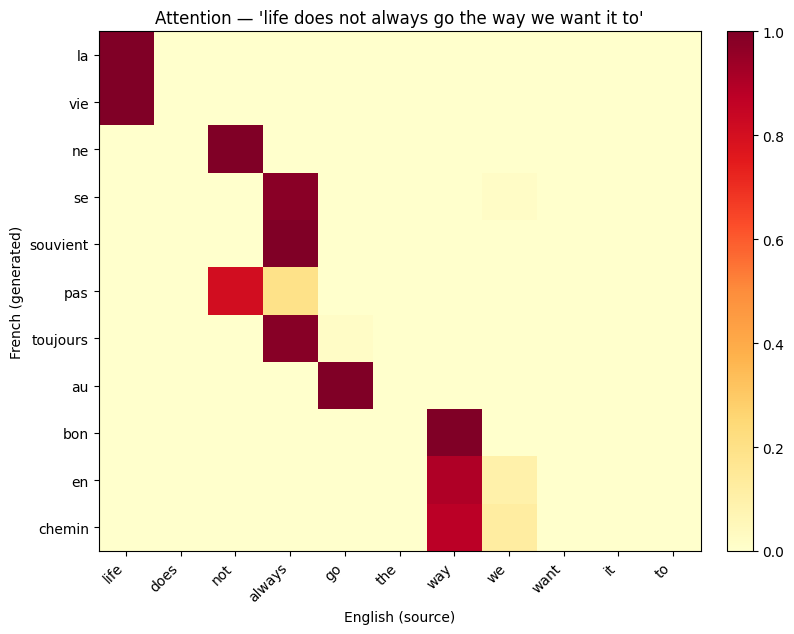

In [ ]:
demo_sentence = test_df.sample(1, random_state=1).iloc[0]["English"]
pred, src_toks, tgt_toks, attn = translate_sentence(demo_sentence, return_attention=True)
print(f"EN : {demo_sentence}")
print(f"FR : {pred}")
plot_attention(src_toks, tgt_toks, attn, title=f"Attention — '{demo_sentence}'")


## 13. Try your own sentences

Type any short English sentence. Keep it close to everyday spoken English — that is what this corpus looks like.


In [ ]:
your_sentences = [
    "Hi.",
    "Run!",
    "I love you.",
    "Where is the bathroom?",
    "I am not ready yet.",
    "Can you help me please?",
]

for s in your_sentences:
    print(f"{s:28s} →  {translate_sentence(s)}")


Hi.                          →  salut
Run!                         →  
I love you.                  →  j adore vous
Where is the bathroom?       →  où sont les toilettes
I am not ready yet.          →  je ne suis pas encore prête
Can you help me please?      →  peux tu m aider s il vous plait


## 14. Save the model

You can reload `seq2seq_en_fr.pt` later without retraining. The checkpoint stores vocabularies as well, because IDs are meaningless without them.


In [ ]:
ckpt_path = Path("seq2seq_en_fr.pt")
torch.save(
    {
        "model_state": model.state_dict(),
        "config": CONFIG,
        "src_word2idx": src_vocab.word2idx,
        "tgt_word2idx": tgt_vocab.word2idx,
    },
    ckpt_path,
)
print(f"Saved checkpoint → {ckpt_path.resolve()}")


Saved checkpoint → /content/seq2seq_en_fr.pt


## 15. Workshop recap

| Piece | What it did |
|---|---|
| Cleaning | Normalized text so `Don't` and `do not` look the same |
| Vocabulary | Mapped words ↔ IDs, with `<pad> / <unk> / <start> / <end>` |
| Encoder (BiLSTM) | Read English forwards and backwards |
| Attention | Let each French word look at the relevant English words |
| Decoder (LSTM) | Wrote French one token at a time |
| Teacher forcing | Fed the true previous word during training |
| Greedy decode | Fed the model’s own previous word at test time |
| `ignore_index` | Stopped padding from inflating accuracy |

### Natural next steps (if you have extra time)
- **Beam search** instead of greedy decoding — keep the top-\(k\) hypotheses
- **Scheduled sampling** — mix gold tokens and model tokens during training
- **BLEU / chrF** — standard MT metrics (token accuracy is only a proxy)
- **Subword tokenization** (BPE / SentencePiece) — handles rare words better than a hard 8k vocab
- **Transformers** — replace LSTMs with self-attention (the modern default), You will now that topic in the next session.


----------------------

*I will start my work from here, i will be using everything initlaized in this notebook. i will use word2vec because i used it before*

note: the model shows overfitting, i will try to fix it in my implementation

# 16. Word2Vec

The original Seq2Seq model learns its embedding vectors from random initialization.

In this extension, Word2Vec will is used to learn meaningful word representations before training the translation model.

Two separate Word2Vec models are trained:

- English Word2Vec for Encoder embeddings
- French Word2Vec for Decoder embeddings

In [ ]:
%pip install -q gensim sacrebleu rouge-score

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 52.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.6/129.6 kB 8.2 MB/s eta 0:00:00


In [ ]:
from gensim.models import Word2Vec
import sacrebleu
from rouge_score import rouge_scorer
from tqdm.auto import tqdm

## 17. Baseline evaluation

Before introducing Word2Vec, the original model is evaluated using BLEU and ROUGE. i will compare these results with the Word2Vec based model.

In [ ]:
@torch.no_grad()
def translate_with_model(model_to_use, sentence: str, max_len=None):
    model_to_use.eval()

    max_len = max_len or CONFIG["max_seq_len"]

    # Same preprocessing
    cleaned = clean_english(sentence)

    src_ids, src_len = src_vocab.encode(
        cleaned,
        CONFIG["max_seq_len"],
        add_special=False
    )

    src = torch.tensor(
        src_ids,
        dtype=torch.long,
        device=device
    ).unsqueeze(0)

    # Encoder
    encoder_outputs, hidden, cell = model_to_use.encoder(src)

    src_mask = model_to_use.create_src_mask(src)

    # Decoder starts with <start>
    token = torch.tensor(
        [[tgt_vocab.sos_idx]],
        dtype=torch.long,
        device=device
    )

    output_ids = []

    # Autoregressive decoding
    for _ in range(max_len):

        logits, hidden, cell, _ = model_to_use.decoder(
            token,
            hidden,
            cell,
            encoder_outputs,
            src_mask
        )

        next_id = int(logits[0, -1].argmax())

        # Stop when <end> is predicted
        if next_id == tgt_vocab.eos_idx:
            break

        output_ids.append(next_id)

        token = torch.tensor(
            [[next_id]],
            dtype=torch.long,
            device=device
        )

    return tgt_vocab.decode(output_ids)

In [ ]:
def calculate_bleu_rouge(predictions, references):
    # BLEU
    bleu = sacrebleu.corpus_bleu(
        predictions,
        [references],
        tokenize="none"
    ).score

    # ROUGE
    scorer = rouge_scorer.RougeScorer(
        ["rouge1", "rouge2", "rougeL"],
        use_stemmer=False
    )

    rouge1_scores = []
    rouge2_scores = []
    rougeL_scores = []

    for reference, prediction in zip(references, predictions):

        scores = scorer.score(
            reference,
            prediction
        )

        rouge1_scores.append(scores["rouge1"].fmeasure)
        rouge2_scores.append(scores["rouge2"].fmeasure)
        rougeL_scores.append(scores["rougeL"].fmeasure)

    return {
        "BLEU": bleu,
        "ROUGE-1": np.mean(rouge1_scores),
        "ROUGE-2": np.mean(rouge2_scores),
        "ROUGE-L": np.mean(rougeL_scores),
    }

In [ ]:
def generate_test_predictions(model_to_use, dataframe, description="Translating"):
    predictions = []

    for sentence in tqdm(dataframe["English"].tolist(),desc=description):

        prediction = translate_with_model(
            model_to_use,
            sentence
        )

        predictions.append(prediction)

    return predictions

In [ ]:
baseline_model = model

baseline_references = test_df["French"].tolist()

baseline_predictions = generate_test_predictions(
    baseline_model,
    test_df,
    description="Baseline translations"
)

baseline_metrics = calculate_bleu_rouge(
    baseline_predictions,
    baseline_references
)

print("\nBASELINE RESULTS")
print("=" * 40)

for metric, value in baseline_metrics.items():
    print(f"{metric:10s}: {value:.4f}")

Baseline translations:   0%|          | 0/4000 [00:00<?, ?it/s]


BASELINE RESULTS
BLEU      : 30.8095
ROUGE-1   : 0.5798
ROUGE-2   : 0.3805
ROUGE-L   : 0.5698



*   **BLEU**: This metric measures the similarity between the machine-translated text and a set of human-translated reference texts. A higher BLEU score means a better quality translation. BLEU score of 30.8095 means a medium level of quality for the French translations.

*   **ROUGE**: ROUGE measure the overlap of n-grams (sequences of words) between the candidate translation and the reference translation.
    *   **ROUGE-1 (0.5798)**: Measures the overlap of unigrams (single words).
    *   **ROUGE-2 (0.3805)**: Measures the overlap of bigrams (pairs of words).
    *   **ROUGE-L (0.5698)**: Measures the longest common subsequence
  

In [ ]:
baseline_test_loss = test_loss
baseline_test_acc = test_acc

print(f"Baseline Test Loss    : {baseline_test_loss:.4f}")
print(f"Baseline Test Accuracy: {baseline_test_acc:.4f}")

Baseline Test Loss    : 1.7030
Baseline Test Accuracy: 0.6536


## 18. Training Word2Vec embeddings

Separate Word2Vec models are trained for English and French.

Skip-gram is selected because it provides useful representations
for less frequent words.

In [ ]:
WORD2VEC_CONFIG = {
    "vector_size": CONFIG["embed_dim"],   # 256 to matches existing model
    "window": 5,
    "min_count": 1,
    "sg": 1,                              # 1 = Skip-gram
    "negative": 10,
    "epochs": 10,
    "workers": 4,
    "seed": SEED,
}

print("Word2Vec configuration:")

for key, value in WORD2VEC_CONFIG.items():
    print(f"{key:15s}: {value}")

Word2Vec configuration:
vector_size    : 256
window         : 5
min_count      : 1
sg             : 1
negative       : 10
epochs         : 10
workers        : 4
seed           : 42


In [ ]:
english_w2v_sentences = [
    sentence.split()
    for sentence in train_df["English"]
]

french_w2v_sentences = [
    sentence.split()
    for sentence in train_df["French"]
]

print("English training sentences:", len(english_w2v_sentences))
print("French training sentences :", len(french_w2v_sentences))

print("\nExample English:")
print(english_w2v_sentences[0])

print("\nExample French:")
print(french_w2v_sentences[0])

English training sentences: 32400
French training sentences : 32400

Example English:
['i', 'spent', 'my', 'vacation', 'in', 'a', 'foreign', 'country']

Example French:
['je', 'ai', 'passé', 'mes', 'vacances', 'dans', 'un', 'pays', 'étranger']


In [ ]:
src_word2vec = Word2Vec(
    sentences=english_w2v_sentences,
    vector_size=WORD2VEC_CONFIG["vector_size"],
    window=WORD2VEC_CONFIG["window"],
    min_count=WORD2VEC_CONFIG["min_count"],
    sg=WORD2VEC_CONFIG["sg"],
    negative=WORD2VEC_CONFIG["negative"],
    epochs=WORD2VEC_CONFIG["epochs"],
    workers=WORD2VEC_CONFIG["workers"],
    seed=WORD2VEC_CONFIG["seed"],
)

print("English Word2Vec finished.")
print("Word2Vec vocabulary size:", len(src_word2vec.wv))

English Word2Vec finished.
Word2Vec vocabulary size: 7729


finished training the english, now the french

In [ ]:
tgt_word2vec = Word2Vec(
    sentences=french_w2v_sentences,
    vector_size=WORD2VEC_CONFIG["vector_size"],
    window=WORD2VEC_CONFIG["window"],
    min_count=WORD2VEC_CONFIG["min_count"],
    sg=WORD2VEC_CONFIG["sg"],
    negative=WORD2VEC_CONFIG["negative"],
    epochs=WORD2VEC_CONFIG["epochs"],
    workers=WORD2VEC_CONFIG["workers"],
    seed=WORD2VEC_CONFIG["seed"],
)

print("French Word2Vec finished.")
print("Word2Vec vocabulary size:", len(tgt_word2vec.wv))

French Word2Vec finished.
Word2Vec vocabulary size: 12133


noticed how the vocab size for french is nearly double :Sob:

In [ ]:
def show_similar_words(w2v_model, word, n=5):

    if word not in w2v_model.wv:
        print(f"'{word}' is not in the Word2Vec vocabulary.")
        return

    print(f"\nWords similar to '{word}':")

    for similar_word, similarity in w2v_model.wv.most_similar(
        word,
        topn=n
    ):
        print(
            f"{similar_word:15s} "
            f"similarity={similarity:.3f}"
        )

In [ ]:
show_similar_words(src_word2vec, "good")
show_similar_words(src_word2vec, "love")
show_similar_words(src_word2vec, "happy")
print("\n=========\n")
show_similar_words(tgt_word2vec, "bon")
show_similar_words(tgt_word2vec, "amour")


Words similar to 'good':
great           similarity=0.725
nice            similarity=0.684
wonderful       similarity=0.674
terrible        similarity=0.648
wise            similarity=0.645

Words similar to 'love':
agree           similarity=0.711
hate            similarity=0.694
sight           similarity=0.692
pleased         similarity=0.683
loved           similarity=0.682

Words similar to 'happy':
pleased         similarity=0.889
impressed       similarity=0.877
satisfied       similarity=0.858
drunk           similarity=0.824
dead            similarity=0.820



Words similar to 'bon':
excellent       similarity=0.746
merveilleux     similarity=0.725
beau            similarity=0.713
proverbe        similarity=0.709
sympa           similarity=0.707

Words similar to 'amour':
expérience      similarity=0.913
éducation       similarity=0.882
espoir          similarity=0.877
amitié          similarity=0.865
trouva          similarity=0.865


In [ ]:
def create_word2vec_embedding_matrix(vocab,word2vec_model,embedding_dim):
    # Create an embedding matrix aligned with the notebook's Vocabulary IDs.


    # Start special tokens with small random vectors.
    matrix = torch.empty(
        len(vocab),
        embedding_dim,
        dtype=torch.float32
    )

    nn.init.normal_(
        matrix,
        mean=0.0,
        std=0.05
    )

    matrix[vocab.pad_idx].zero_()

    covered = 0

    special_tokens = {
        vocab.PAD,
        vocab.UNK,
        vocab.SOS,
        vocab.EOS,
    }

    for word, idx in vocab.word2idx.items():

        if word in special_tokens:
            continue

        if word in word2vec_model.wv:

            vector = word2vec_model.wv[word]

            matrix[idx] = torch.tensor(
                vector,
                dtype=torch.float32
            )

            covered += 1

    # Give <unk> the average Word2Vec vector.
    mean_vector = word2vec_model.wv.vectors.mean(axis=0)

    matrix[vocab.unk_idx] = torch.tensor(
        mean_vector,
        dtype=torch.float32
    )

    total_normal_words = max(len(vocab) - 4, 1)

    coverage = covered / total_normal_words

    print(
        f"Covered {covered:,}/{total_normal_words:,} "
        f"words ({coverage:.2%})"
    )

    return matrix

In [ ]:
print("English embedding matrix:")
src_embedding_matrix = create_word2vec_embedding_matrix(
    src_vocab,
    src_word2vec,
    CONFIG["embed_dim"]
)

print("\nFrench embedding matrix:")
tgt_embedding_matrix = create_word2vec_embedding_matrix(
    tgt_vocab,
    tgt_word2vec,
    CONFIG["embed_dim"]
)

print("\nShapes:")
print("English:", src_embedding_matrix.shape)
print("French :", tgt_embedding_matrix.shape)

English embedding matrix:
Covered 7,729/7,729 words (100.00%)

French embedding matrix:
Covered 7,996/7,996 words (100.00%)

Shapes:
English: torch.Size([7733, 256])
French : torch.Size([8000, 256])


In [ ]:
example_word = "happy" # just a test

if example_word in src_vocab.word2idx and example_word in src_word2vec.wv:

    idx = src_vocab.word2idx[example_word]

    matrix_vector = src_embedding_matrix[idx].numpy()
    word2vec_vector = src_word2vec.wv[example_word]

    print("Word:", example_word)
    print("Vocabulary ID:", idx)

    print(
        "Vectors identical:",
        np.allclose(
            matrix_vector,
            word2vec_vector
        )
    )

Word: happy
Vocabulary ID: 137
Vectors identical: True


okay it is working, matched the same vocab id

In [ ]:
W2V_TRAIN_CONFIG = {
    "epochs": 12,
    "dropout": 0.30, # Higher than the original because of overfitting
    "learning_rate": 1e-3,
    "weight_decay": 1e-4, # AdamW
    "label_smoothing": 0.10,
    "patience": 3,
    "min_delta": 0.005, # Tiny changes do not count as improvement
    "grad_clip": 1.0,
}

print("Word2Vec training configuration:")

for key, value in W2V_TRAIN_CONFIG.items():
    print(f"{key:18s}: {value}")

Word2Vec training configuration:
epochs            : 12
dropout           : 0.3
learning_rate     : 0.001
weight_decay      : 0.0001
label_smoothing   : 0.1
patience          : 3
min_delta         : 0.005
grad_clip         : 1.0


In [ ]:
encoder = Encoder(
    vocab_size=len(src_vocab),
    embed_dim=CONFIG["embed_dim"],
    hidden_dim=CONFIG["hidden_dim"],
    pad_idx=src_vocab.pad_idx,
    dropout=W2V_TRAIN_CONFIG["dropout"],
)

decoder = Decoder(
    vocab_size=len(tgt_vocab),
    embed_dim=CONFIG["embed_dim"],
    hidden_dim=CONFIG["decoder_hidden"],
    pad_idx=tgt_vocab.pad_idx,
    dropout=W2V_TRAIN_CONFIG["dropout"],
)

In [ ]:
with torch.no_grad():

    encoder.embedding.weight.copy_(
        src_embedding_matrix
    )

    decoder.embedding.weight.copy_(
        tgt_embedding_matrix
    )

In [ ]:
encoder.embedding.weight.requires_grad = True #fine tuning the embeddings (first time hearing about it)
decoder.embedding.weight.requires_grad = True

apparently fine tuning embeddings adapts a pre-trained vector representation to better capture domain-specific semantic relationships, boosting retrieval accuracy by 10% to 25% for tasks like semantic search. it is very popular in RAG

In [ ]:
model = Seq2Seq(
    encoder,
    decoder,
    pad_idx=src_vocab.pad_idx
).to(device)

n_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(model)

print(
    f"\nTrainable parameters: "
    f"{n_params:,}"
)

Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(7733, 256, padding_idx=0)
    (lstm): LSTM(256, 256, batch_first=True, bidirectional=True)
    (dropout): Dropout(p=0.3, inplace=False)
  )
  (decoder): Decoder(
    (embedding): Embedding(8000, 256, padding_idx=0)
    (lstm): LSTM(256, 512, batch_first=True)
    (attention): LuongAttention()
    (fc): Linear(in_features=1024, out_features=8000, bias=True)
    (dropout): Dropout(p=0.3, inplace=False)
  )
)

Trainable parameters: 14,857,280


In [ ]:
criterion_w2v = nn.CrossEntropyLoss(
    ignore_index=tgt_vocab.pad_idx,
    label_smoothing=W2V_TRAIN_CONFIG["label_smoothing"]
)

plain_criterion = nn.CrossEntropyLoss(
    ignore_index=tgt_vocab.pad_idx
)

optimizer_w2v = torch.optim.AdamW(
    model.parameters(),
    lr=W2V_TRAIN_CONFIG["learning_rate"],
    weight_decay=W2V_TRAIN_CONFIG["weight_decay"]
)

scheduler_w2v = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_w2v,
    mode="min",
    factor=0.5,
    patience=1
)

In [ ]:
def run_word2vec_epoch(loader, train=True):

    if train:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    context = (
        torch.enable_grad()
        if train
        else torch.no_grad()
    )

    with context:

        for batch in loader:

            src = batch["src"].to(device)
            tgt_in = batch["tgt_in"].to(device)
            tgt_out = batch["tgt_out"].to(device)


            logits, _ = model(
                src,
                tgt_in
            )

            loss = criterion_w2v(
                logits.reshape(
                    -1,
                    logits.size(-1)
                ),
                tgt_out.reshape(-1)
            )


            if train:

                optimizer_w2v.zero_grad(
                    set_to_none=True
                )

                loss.backward()

                nn.utils.clip_grad_norm_(
                    model.parameters(),
                    W2V_TRAIN_CONFIG["grad_clip"]
                )

                optimizer_w2v.step()


            total_loss += loss.item()

            total_acc += token_accuracy(
                logits,
                tgt_out,
                tgt_vocab.pad_idx
            )

            n_batches += 1

    return (
        total_loss / max(n_batches, 1),
        total_acc / max(n_batches, 1)
    )

In [ ]:
history_w2v = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": [],
}

best_val = math.inf
best_state = None
best_epoch = 0

stale = 0

t0 = time.time()


print(
    f"{'epoch':>6}  "
    f"{'train_loss':>11}  "
    f"{'val_loss':>9}  "
    f"{'train_acc':>10}  "
    f"{'val_acc':>8}  "
    f"{'lr':>10}  "
    f"{'time':>6}"
)

print("-" * 80)


for epoch in range(
    1,
    W2V_TRAIN_CONFIG["epochs"] + 1
):

    epoch_start = time.time()

    # Training

    train_loss, train_acc = run_word2vec_epoch(
        train_loader,
        train=True
    )


    # Validation
    val_loss, val_acc = run_word2vec_epoch(
        val_loader,
        train=False
    )

    scheduler_w2v.step(val_loss)

    current_lr = optimizer_w2v.param_groups[0]["lr"]

    # Store history
    history_w2v["train_loss"].append(train_loss)
    history_w2v["val_loss"].append(val_loss)
    history_w2v["train_acc"].append(train_acc)
    history_w2v["val_acc"].append(val_acc)

    elapsed = time.time() - epoch_start

    print(
        f"{epoch:6d}  "
        f"{train_loss:11.4f}  "
        f"{val_loss:9.4f}  "
        f"{train_acc:10.3f}  "
        f"{val_acc:8.3f}  "
        f"{current_lr:10.6f}  "
        f"{elapsed:5.0f}s"
    )


    improvement = (
        val_loss
        <
        best_val - W2V_TRAIN_CONFIG["min_delta"]
    )

    if improvement:

        best_val = val_loss
        best_epoch = epoch

        best_state = {
            key: value.detach().cpu().clone()
            for key, value
            in model.state_dict().items()
        }

        stale = 0

    else:

        stale += 1

        if stale >= W2V_TRAIN_CONFIG["patience"]:

            print(
                f"\nEarly stopping at epoch {epoch}."
            )

            print(
                f"Best epoch: {best_epoch}"
            )

            print(
                f"Best validation loss: "
                f"{best_val:.4f}"
            )

            break

 epoch   train_loss   val_loss   train_acc   val_acc          lr    time
--------------------------------------------------------------------------------
     1       4.8281     3.6740       0.338     0.480    0.001000     16s
     2       3.3560     3.0765       0.537     0.586    0.001000     17s
     3       2.8017     2.8710       0.632     0.633    0.001000     17s
     4       2.4696     2.7567       0.696     0.656    0.001000     17s
     5       2.2412     2.7074       0.749     0.670    0.001000     17s
     6       2.0788     2.6868       0.790     0.679    0.001000     17s
     7       1.9631     2.6749       0.821     0.681    0.001000     17s
     8       1.8729     2.6703       0.845     0.685    0.001000     18s
     9       1.8058     2.6672       0.863     0.687    0.001000     18s
    10       1.7506     2.6758       0.879     0.685    0.001000     18s
    11       1.7041     2.6874       0.892     0.685    0.000500     18s
    12       1.6189     2.6525       0.918 

In [ ]:
if best_state is not None:

    model.load_state_dict(best_state)
    model.to(device)


print(
    f"\nTraining finished in "
    f"{(time.time() - t0) / 60:.1f} minutes."
)

print(
    f"Best epoch: {best_epoch}"
)

print(
    f"Best validation loss: "
    f"{best_val:.4f}"
)


Training finished in 4.3 minutes.
Best epoch: 12
Best validation loss: 2.6525


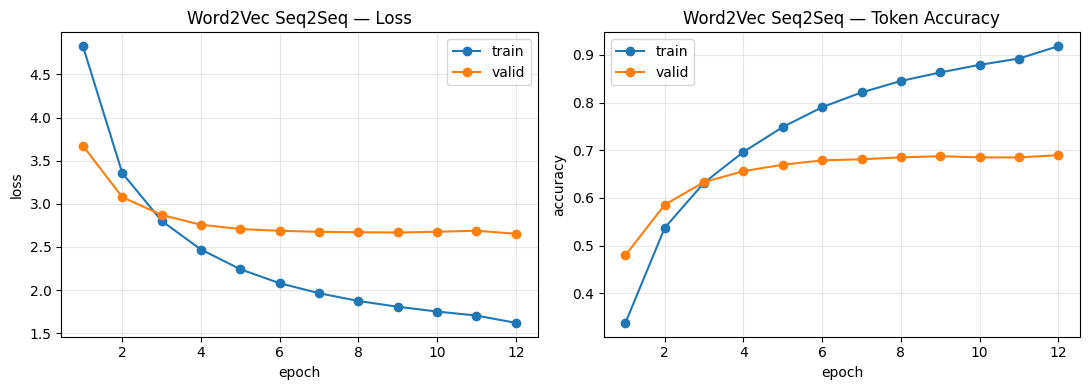

In [ ]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(11, 4)
)

epochs_x = range(
    1,
    len(history_w2v["train_loss"]) + 1
)


# Loss
axes[0].plot(
    epochs_x,
    history_w2v["train_loss"],
    marker="o",
    label="train"
)

axes[0].plot(
    epochs_x,
    history_w2v["val_loss"],
    marker="o",
    label="valid"
)

axes[0].set_title(
    "Word2Vec Seq2Seq — Loss"
)

axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss")

axes[0].legend()
axes[0].grid(alpha=0.3)


# Accuracy
axes[1].plot(
    epochs_x,
    history_w2v["train_acc"],
    marker="o",
    label="train"
)

axes[1].plot(
    epochs_x,
    history_w2v["val_acc"],
    marker="o",
    label="valid"
)

axes[1].set_title(
    "Word2Vec Seq2Seq — Token Accuracy"
)

axes[1].set_xlabel("epoch")
axes[1].set_ylabel("accuracy")

axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
@torch.no_grad()
def evaluate_test_loss_accuracy(
    model_to_use,
    loader
):

    model_to_use.eval()

    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for batch in loader:

        src = batch["src"].to(device)
        tgt_in = batch["tgt_in"].to(device)
        tgt_out = batch["tgt_out"].to(device)

        logits, _ = model_to_use(
            src,
            tgt_in
        )

        loss = plain_criterion(
            logits.reshape(
                -1,
                logits.size(-1)
            ),
            tgt_out.reshape(-1)
        )

        total_loss += loss.item()

        total_acc += token_accuracy(
            logits,
            tgt_out,
            tgt_vocab.pad_idx
        )

        n_batches += 1

    return (
        total_loss / n_batches,
        total_acc / n_batches
    )

In [ ]:
w2v_test_loss, w2v_test_acc = evaluate_test_loss_accuracy(
    model,
    test_loader
)

print(
    f"Word2Vec Test Loss    : "
    f"{w2v_test_loss:.4f}"
)

print(
    f"Word2Vec Test Accuracy: "
    f"{w2v_test_acc:.4f}"
)

Word2Vec Test Loss    : 1.6192
Word2Vec Test Accuracy: 0.6922


In [ ]:
w2v_references = test_df["French"].tolist()

w2v_predictions = generate_test_predictions(
    model,
    test_df,
    description="Word2Vec translations"
)

Word2Vec translations:   0%|          | 0/4000 [00:00<?, ?it/s]

In [ ]:
w2v_metrics = calculate_bleu_rouge(
    w2v_predictions,
    w2v_references
)

print("\nWORD2VEC RESULTS")
print("=" * 40)

print(
    f"Test Loss : "
    f"{w2v_test_loss:.4f}"
)

print(
    f"Accuracy  : "
    f"{w2v_test_acc:.4f}"
)

for metric, value in w2v_metrics.items():

    print(
        f"{metric:10s}: "
        f"{value:.4f}"
    )


WORD2VEC RESULTS
Test Loss : 1.6192
Accuracy  : 0.6922
BLEU      : 35.4988
ROUGE-1   : 0.6135
ROUGE-2   : 0.4200
ROUGE-L   : 0.6043


In [ ]:
comparison_df = pd.DataFrame([
    {
        "Model": "Original Seq2Seq",
        "Embedding": "Random learned embedding",
        "Test Loss": baseline_test_loss,
        "Token Accuracy": baseline_test_acc,
        "BLEU": baseline_metrics["BLEU"],
        "ROUGE-1": baseline_metrics["ROUGE-1"],
        "ROUGE-2": baseline_metrics["ROUGE-2"],
        "ROUGE-L": baseline_metrics["ROUGE-L"],
    },

    {
        "Model": "Seq2Seq + Word2Vec",
        "Embedding": "Word2Vec Skip-gram",
        "Test Loss": w2v_test_loss,
        "Token Accuracy": w2v_test_acc,
        "BLEU": w2v_metrics["BLEU"],
        "ROUGE-1": w2v_metrics["ROUGE-1"],
        "ROUGE-2": w2v_metrics["ROUGE-2"],
        "ROUGE-L": w2v_metrics["ROUGE-L"],
    },
])

comparison_df

,Model,Embedding,Test Loss,Token Accuracy,BLEU,ROUGE-1,ROUGE-2,ROUGE-L
0,Original Seq2Seq,Random learned embedding,1.702960,0.653558,30.809473,0.579820,0.380455,0.569802
1,Seq2Seq + Word2Vec,Word2Vec Skip-gram,1.619246,0.692183,35.498772,0.613459,0.420012,0.604271


## Comparison: Original Seq2Seq vs. Seq2Seq + Word2Vec

*   **Lower Test Loss**
*   **Higher Token Accuracy**
*   **Significantly Higher BLEU Score**
*   **Improved ROUGE Scores**

These results shows that initializing the encoder and decoder embeddings with pre-trained Word2Vec vectors (even with finetuning) provides a better starting point for the model, leading to better overall performance compared to learning embeddings from scratch with random initialization.

In [ ]:
word2vec_translations_df = show_translations(
    n=12,
    seed=7
)

word2vec_translations_df

,English,Reference (FR),Predicted (FR)
0,after i watched tv i went to bed,après avoir regardé la télévision je suis allé me coucher,après avoir regardé mon vaisselle je ai été au lit
1,i cannot breathe,je n arrive pas à respirer,je ne peux pas respirer
2,tom and mary do not want to talk to john,tom et marie ne veulent pas parler à john,tom et mary ne veulent pas parler de john
3,she asked him to not quit his job,elle l a prié de ne pas quitter son emploi,elle lui a demandé de ne pas avoir son travail
4,i would rather die than do it,je préférerais mourir que de le faire,je préférerais mourir que le le faire
5,do not make me say it,ne me faites pas dire ça,ne me fais pas le dire
6,tom does not want you to get hurt,tom ne veut pas que vous soyez blessée,tom ne veut pas que vous soyez blessé
7,you are in luck,tu es veinarde,tu es veinard
8,what was the first instrument you learned to play,quel était le premier instrument auquel vous avez appris à jouer,quel était le premier instrument auquel tu as appris à jouer
9,if you want me to play the piano i will play the piano,si tu veux que je joue du piano je jouerai du piano,si tu veux que je joue du piano je vais jouer du piano


In [ ]:
comparison_rows = []

indices = random.Random(7).sample(
    range(len(test_df)),
    k=min(12, len(test_df))
)

for i in indices:

    english = test_df.loc[i, "English"]
    reference = test_df.loc[i, "French"]

    baseline_pred = baseline_predictions[i]
    word2vec_pred = w2v_predictions[i]

    comparison_rows.append({
        "English": english,
        "Reference": reference,
        "Baseline": baseline_pred,
        "Word2Vec": word2vec_pred,
    })


translation_comparison_df = pd.DataFrame(
    comparison_rows
)

pd.set_option(
    "display.max_colwidth",
    100
)

translation_comparison_df

,English,Reference,Baseline,Word2Vec
0,after i watched tv i went to bed,après avoir regardé la télévision je suis allé me coucher,après avoir je suis allé la maison au lit,après avoir regardé mon vaisselle je ai été au lit
1,i cannot breathe,je n arrive pas à respirer,je ne peux pas me porter,je ne peux pas respirer
2,tom and mary do not want to talk to john,tom et marie ne veulent pas parler à john,tom et marie ne voulait pas parler parler,tom et mary ne veulent pas parler de john
3,she asked him to not quit his job,elle l a prié de ne pas quitter son emploi,elle lui a demandé de ne pas démissionner son poste,elle lui a demandé de ne pas avoir son travail
4,i would rather die than do it,je préférerais mourir que de le faire,je préférerais plutôt mourir que le faire,je préférerais mourir que le le faire
5,do not make me say it,ne me faites pas dire ça,ne m oblige pas à l esprit,ne me fais pas le dire
6,tom does not want you to get hurt,tom ne veut pas que vous soyez blessée,tom ne veut pas que vous soyez blessé,tom ne veut pas que vous soyez blessé
7,you are in luck,tu es veinarde,tu es en chance,tu es veinard
8,what was the first instrument you learned to play,quel était le premier instrument auquel vous avez appris à jouer,quel a été le premier instrument auquel tu as appris,quel était le premier instrument auquel tu as appris à jouer
9,if you want me to play the piano i will play the piano,si tu veux que je joue du piano je jouerai du piano,si tu veux que je vais me jouer du piano,si tu veux que je joue du piano je vais jouer du piano


English   : life does not always go the way we want it to
Word2Vec  : la vie ne va pas toujours la manière dont nous le voulons


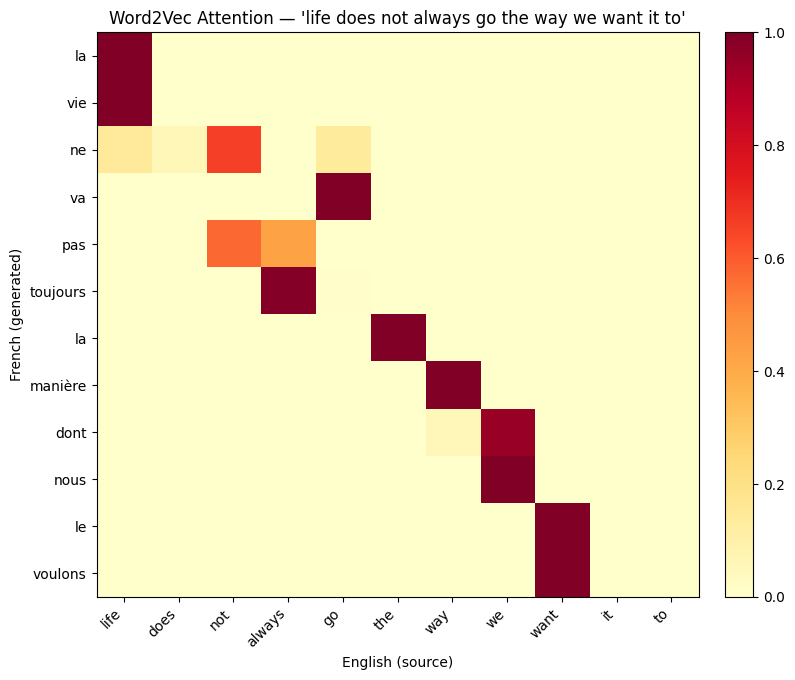

In [ ]:
demo_sentence = test_df.sample(1,random_state=1).iloc[0]["English"]

pred, src_toks, tgt_toks, attn = translate_sentence(
    demo_sentence,
    return_attention=True
)

print(f"English   : {demo_sentence}")

print(f"Word2Vec  : {pred}")

plot_attention(
    src_toks,
    tgt_toks,
    attn,
    title=f"Word2Vec Attention — '{demo_sentence}'"
)

In [ ]:
src_word2vec.save(
    "word2vec_english.model"
)

tgt_word2vec.save(
    "word2vec_french.model"
)

print("Word2Vec models saved.")

Word2Vec models saved.


In [ ]:
word2vec_ckpt_path = Path(
    "seq2seq_word2vec_en_fr.pt"
)

torch.save(
    {
        "model_state": model.state_dict(),

        "base_config": CONFIG,

        "word2vec_config": WORD2VEC_CONFIG,

        "training_config": W2V_TRAIN_CONFIG,

        "embedding_method":
            "Word2Vec Skip-gram",

        "src_word2idx":
            src_vocab.word2idx,

        "tgt_word2idx":
            tgt_vocab.word2idx,

        "best_epoch":
            best_epoch,

        "best_validation_loss":
            best_val,

        "test_loss":
            w2v_test_loss,

        "test_accuracy":
            w2v_test_acc,

        "bleu":
            w2v_metrics["BLEU"],

        "rouge1":
            w2v_metrics["ROUGE-1"],

        "rouge2":
            w2v_metrics["ROUGE-2"],

        "rougeL":
            w2v_metrics["ROUGE-L"],
    },

    word2vec_ckpt_path
)

print(
    f"Saved Word2Vec Seq2Seq checkpoint → "
    f"{word2vec_ckpt_path.resolve()}"
)

Saved Word2Vec Seq2Seq checkpoint → /content/seq2seq_word2vec_en_fr.pt
